In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)

RAW

In [5]:
df=pd.read_csv(r"student_performance_dataset.csv")

In [6]:
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Quiz_Score,Project_Score,Midterm_Exam,Course_Work_Score,Final_Exam_Score,Status
0,8.9,74.1,55.8,48.5,56.2,63.5,53.8,69.1,Pass
1,6.1,57.8,45.8,44.0,39.8,32.4,42.9,44.9,Fail
2,5.8,70.7,64.3,43.5,47.8,40.6,51.5,42.1,Fail
3,5.8,74.5,57.4,56.5,49.1,62.3,53.8,66.4,Pass
4,15.4,59.8,68.0,55.6,80.0,60.8,69.1,69.8,Pass


inspect

In [7]:
df.shape

(10000, 9)

In [8]:
len(df)

10000

In [9]:
df.describe()

,Study_Hours,Attendance_Percentage,Assignment_Score,Quiz_Score,Project_Score,Midterm_Exam,Course_Work_Score,Final_Exam_Score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.55698,69.140710,55.798460,48.965540,57.697890,54.591620,54.508110,51.725240
std,4.25483,9.435288,13.009303,13.952325,13.016407,15.951284,11.692547,17.191149
min,0.30000,40.000000,11.100000,6.600000,19.900000,0.000000,21.400000,3.200000
25%,4.40000,62.600000,46.700000,39.400000,48.575000,43.500000,46.100000,39.575000
50%,6.70000,68.700000,54.600000,48.000000,56.600000,53.200000,53.000000,49.800000
75%,9.80000,75.300000,63.800000,57.500000,65.600000,64.300000,61.400000,61.900000
max,25.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            10000 non-null  float64
 1   Attendance_Percentage  10000 non-null  float64
 2   Assignment_Score       10000 non-null  float64
 3   Quiz_Score             10000 non-null  float64
 4   Project_Score          10000 non-null  float64
 5   Midterm_Exam           10000 non-null  float64
 6   Course_Work_Score      10000 non-null  float64
 7   Final_Exam_Score       10000 non-null  float64
 8   Status                 10000 non-null  str    
dtypes: float64(8), str(1)
memory usage: 703.3 KB


In [11]:
object_data = df.select_dtypes(include="object")

print("Object columns:")
print(object_data.columns.tolist())

object_data.head()

Object columns:
['Status']


,Status
0,Pass
1,Fail
2,Fail
3,Pass
4,Pass


In [12]:
missing_raw = df.isna().sum().to_frame("Missing_Count")
missing_raw["Missing_%"] = (df.isna().mean() * 100).round(2)

missing_raw.sort_values("Missing_%", ascending=False)

,Missing_Count,Missing_%
Study_Hours,0,0.0
Attendance_Percentage,0,0.0
Assignment_Score,0,0.0
Quiz_Score,0,0.0
Project_Score,0,0.0
Midterm_Exam,0,0.0
Course_Work_Score,0,0.0
Final_Exam_Score,0,0.0
Status,0,0.0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,Study_Hours,Attendance_Percentage,Assignment_Score,Quiz_Score,Project_Score,Midterm_Exam,Course_Work_Score,Final_Exam_Score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.55698,69.140710,55.798460,48.965540,57.697890,54.591620,54.508110,51.725240
std,4.25483,9.435288,13.009303,13.952325,13.016407,15.951284,11.692547,17.191149
min,0.30000,40.000000,11.100000,6.600000,19.900000,0.000000,21.400000,3.200000
25%,4.40000,62.600000,46.700000,39.400000,48.575000,43.500000,46.100000,39.575000
50%,6.70000,68.700000,54.600000,48.000000,56.600000,53.200000,53.000000,49.800000
75%,9.80000,75.300000,63.800000,57.500000,65.600000,64.300000,61.400000,61.900000
max,25.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [15]:
df.loc[~df["Course_Work_Score"].between(0, 100), "Course_Work_Score"] = np.nan

In [16]:
df.loc[~df["Assignment_Score"].between(0, 100), "Assignment_Score"] = np.nan

In [17]:
df.loc[~df["Quiz_Score"].between(0, 100), "Quiz_Score"] = np.nan

In [18]:
df.loc[~df["Project_Score"].between(0,100),"Project_Score"]=np.nan

In [19]:
df["Status"].value_counts()

Status
Pass    5459
Fail    4541
Name: count, dtype: int64

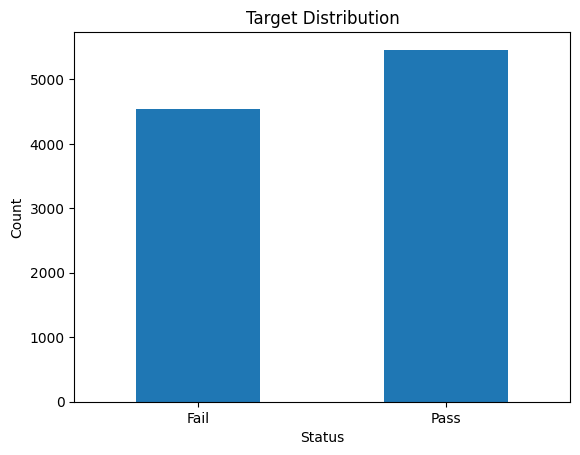

In [20]:
df["Status"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

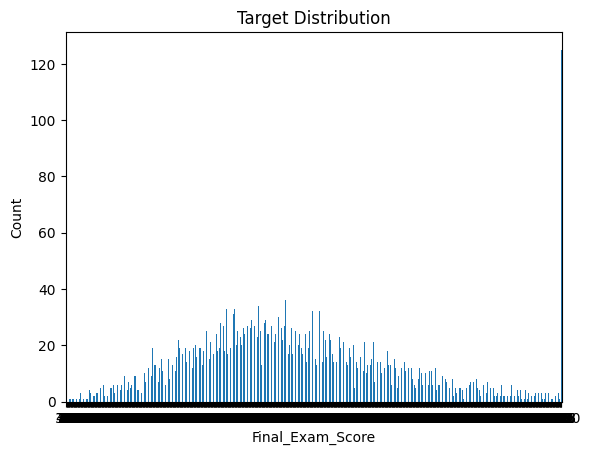

In [21]:

df["Final_Exam_Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Final_Exam_Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [22]:
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols

Index(['Study_Hours', 'Attendance_Percentage', 'Assignment_Score',
       'Quiz_Score', 'Project_Score', 'Midterm_Exam', 'Course_Work_Score',
       'Final_Exam_Score'],
      dtype='str')

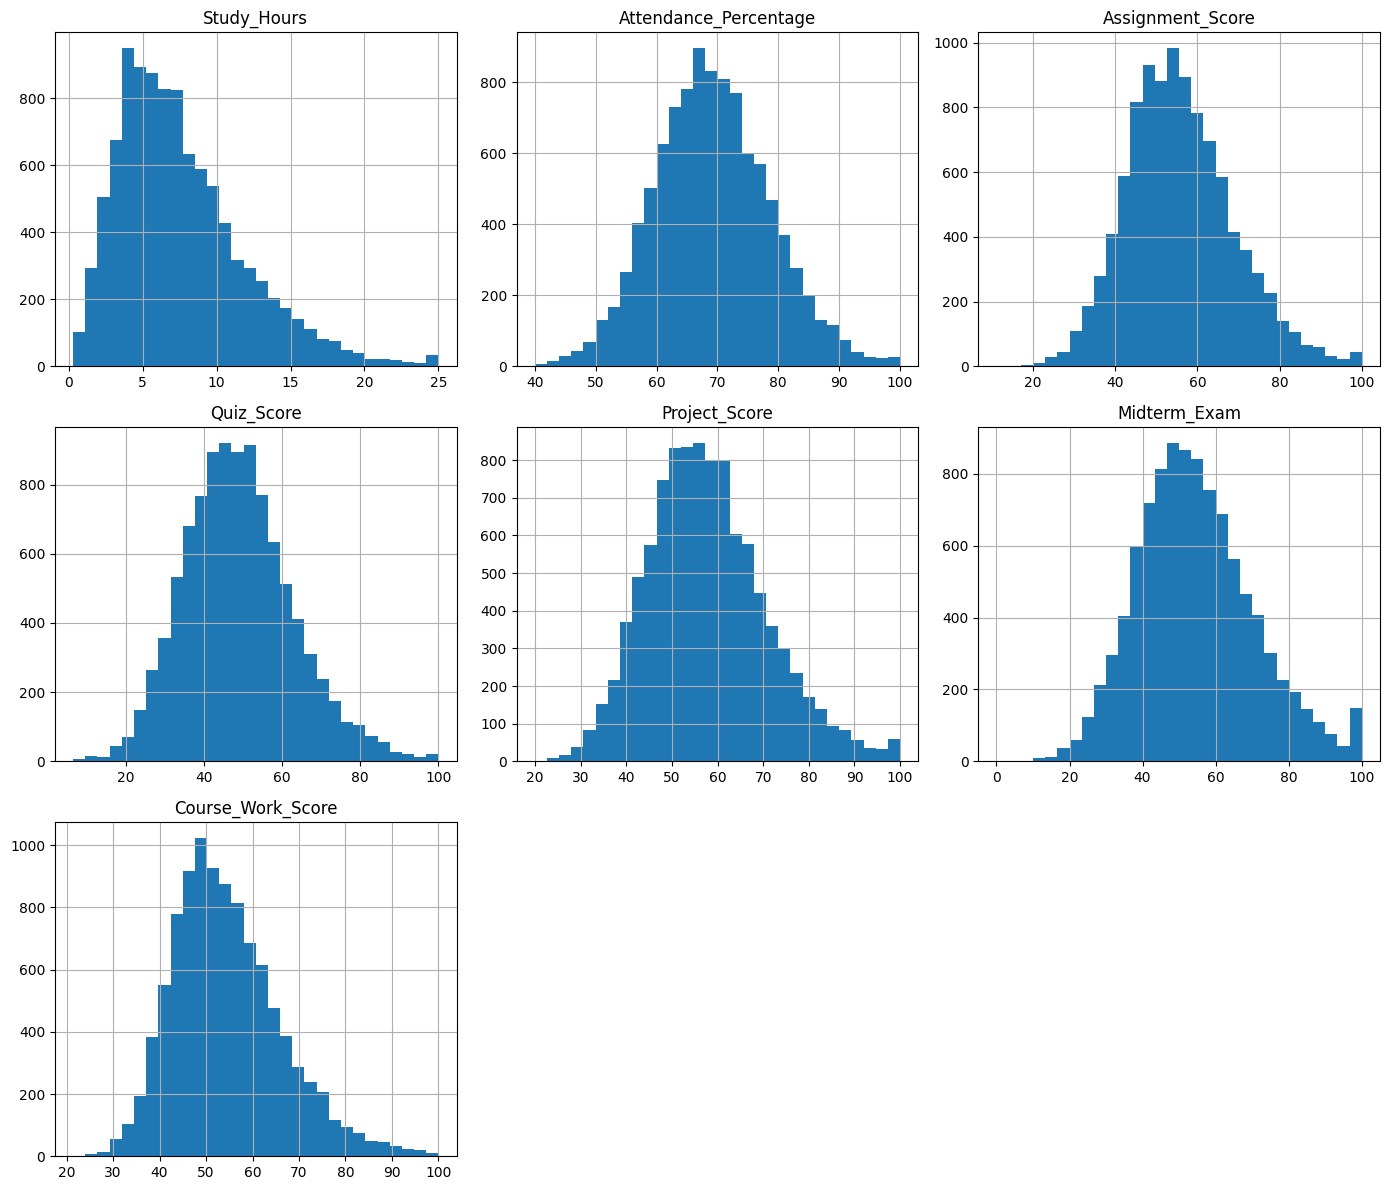

In [23]:
numeric_cols = df.select_dtypes(include="number").columns

numeric_cols = numeric_cols.drop(["Final_Exam_Score", "Status"], errors="ignore")

df[numeric_cols].hist(figsize=(14, 12), bins=30)

plt.tight_layout()
plt.show()

In [24]:
df[numeric_cols].skew().round(3).sort_values(key=abs, ascending=False)

Study_Hours              1.038
Course_Work_Score        0.683
Project_Score            0.484
Assignment_Score         0.448
Midterm_Exam             0.435
Quiz_Score               0.416
Attendance_Percentage    0.195
dtype: float64

In [25]:
numeric_cols = df.select_dtypes(include="number").columns

print(numeric_cols)

Index(['Study_Hours', 'Attendance_Percentage', 'Assignment_Score',
       'Quiz_Score', 'Project_Score', 'Midterm_Exam', 'Course_Work_Score',
       'Final_Exam_Score'],
      dtype='str')


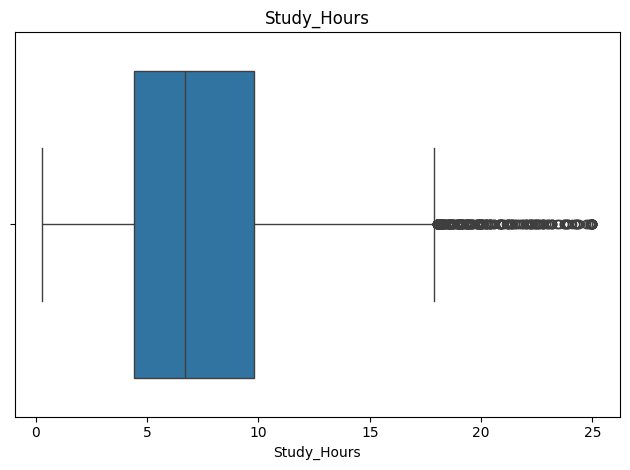

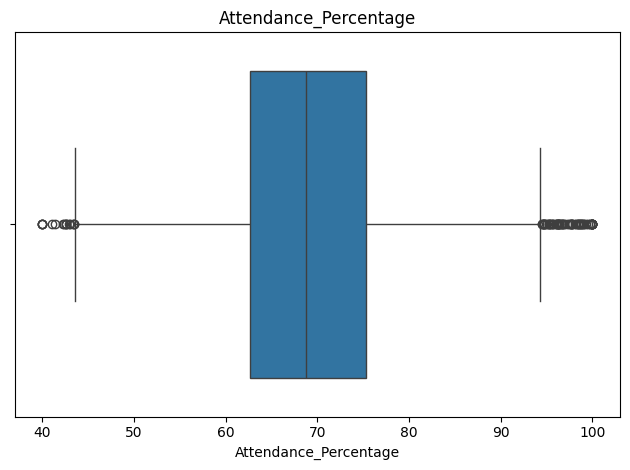

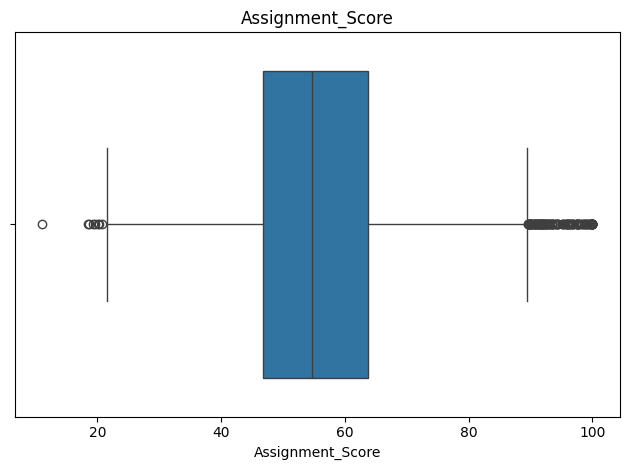

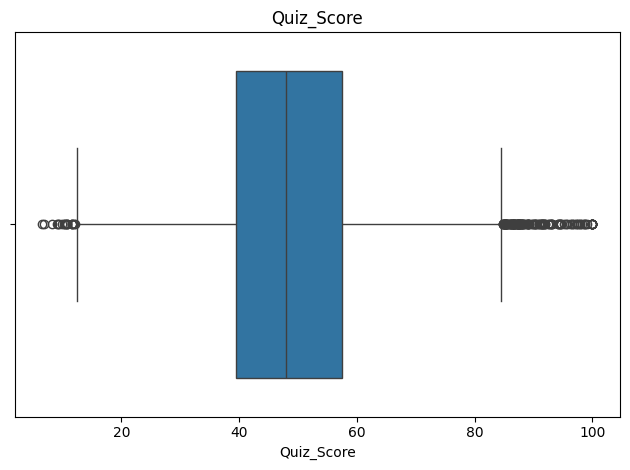

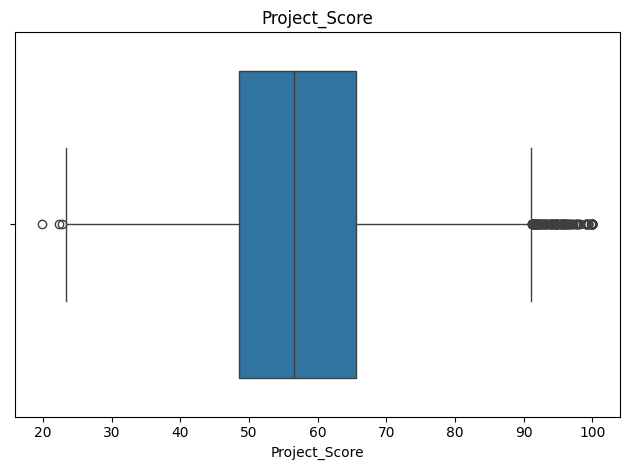

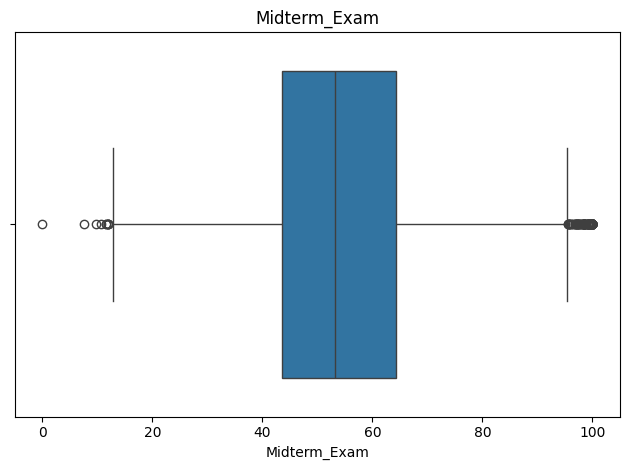

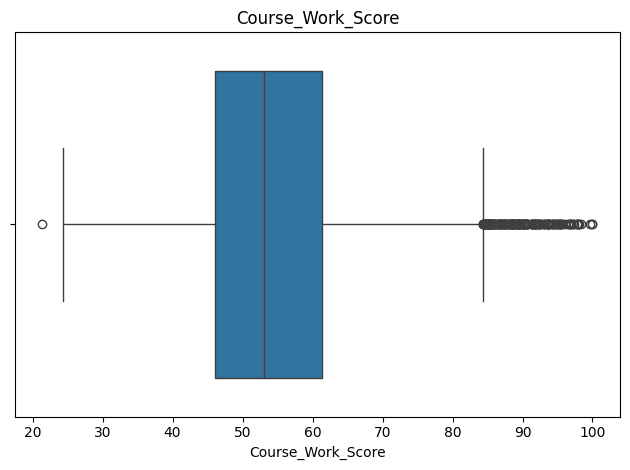

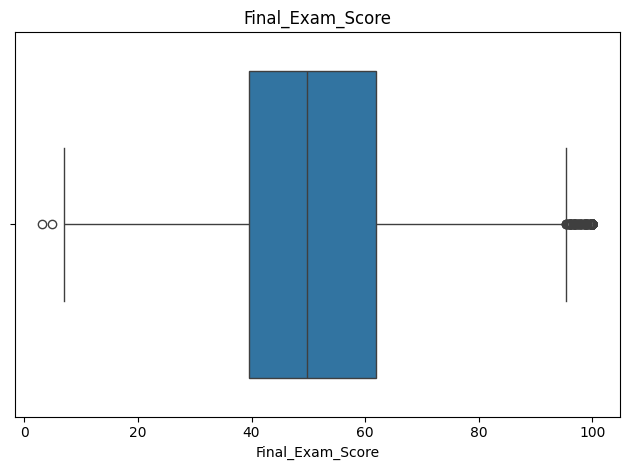

In [26]:
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [27]:
categorical_cols_eda = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols_eda)

for col in categorical_cols_eda:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


Categorical columns:
['Status']

 Status
Status
Pass    5459
Fail    4541
Name: count, dtype: int64


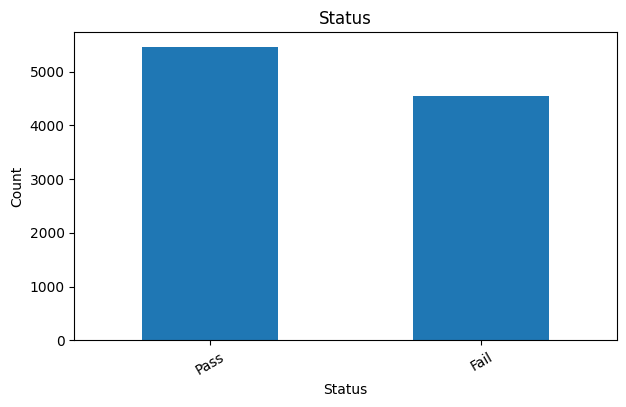

In [28]:
for col in categorical_cols_eda:
    df[col].value_counts(dropna=False).plot(kind="bar", figsize=(7, 4))
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

In [29]:
X = df.drop(columns=["Status"])


y= df["Status"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y # make sure the same percentage of random of split for xtrain an xtest to be the same ratio
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain class %:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class %:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train: (8000, 8)
Test : (2000, 8)

Train class %:
Status
Pass    54.59
Fail    45.41
Name: proportion, dtype: float64

Test class %:
Status
Pass    54.6
Fail    45.4
Name: proportion, dtype: float64


In [31]:
X_train.head(5)

,Study_Hours,Attendance_Percentage,Assignment_Score,Quiz_Score,Project_Score,Midterm_Exam,Course_Work_Score,Final_Exam_Score
8647,7.6,81.8,41.0,44.5,52.9,50.7,46.8,42.2
8143,6.1,60.4,34.8,39.8,46.2,49.6,40.9,51.0
8253,6.0,60.6,39.4,40.8,49.9,56.6,44.0,44.1
1905,6.1,79.1,60.1,59.2,66.9,74.6,62.6,44.4
5662,16.2,78.4,79.7,69.2,69.3,76.9,72.4,77.5


In [32]:
missing_train = X_train.isna().sum().to_frame("Missing_Count")

missing_train["Missing_%"] = (X_train.isna().mean() * 100).round(2)

missing_train["Data_Type"] = X_train.dtypes.astype(str)

missing_train.sort_values("Missing_%", ascending=False)

,Missing_Count,Missing_%,Data_Type
Study_Hours,0,0.0,float64
Attendance_Percentage,0,0.0,float64
Assignment_Score,0,0.0,float64
Quiz_Score,0,0.0,float64
Project_Score,0,0.0,float64
Midterm_Exam,0,0.0,float64
Course_Work_Score,0,0.0,float64
Final_Exam_Score,0,0.0,float64


In [33]:
numeric= ['Study_Hours', 'Attendance_Percentage', 'Assignment_Score',
       'Quiz_Score', 'Project_Score', 'Midterm_Exam', 'Course_Work_Score',
       'Final_Exam_Score'
]
print("\nSkewness:")
print(X_train[numeric].skew().round(3))


Skewness:
Study_Hours              1.028
Attendance_Percentage    0.199
Assignment_Score         0.461
Quiz_Score               0.425
Project_Score            0.478
Midterm_Exam             0.442
Course_Work_Score        0.681
Final_Exam_Score         0.515
dtype: float64


In [34]:
numeric_check_cols = [
    'Study_Hours', 'Attendance_Percentage', 'Assignment_Score',
       'Quiz_Score', 'Project_Score', 'Midterm_Exam', 'Course_Work_Score',
       'Final_Exam_Score'
]

for col in numeric_check_cols:
    data = X_train[col]

    q1 = data.quantile(0.25) #25%
    q3 = data.quantile(0.75) #75%
    iqr = q3 - q1 #50%
    lower = q1 - 1.5 * iqr  
    upper = q3 + 1.5 * iqr 
    iqr_outliers = ((data < lower) | (data > upper)).sum()
    #--------------------------------------------------------------
    z = ((data - data.mean()) / data.std()).abs() # x-mean/std
    z_outliers = (z > 3).sum()

    print("\n", col)
    print("Skewness:", round(data.skew(), 3))
    print("IQR outliers:", iqr_outliers)
    print("Z > 3:", z_outliers)
    print("Min:", round(data.min(), 2))
    print("Max:", round(data.max(), 2))


 Study_Hours
Skewness: 1.028
IQR outliers: 193
Z > 3: 83
Min: 0.3
Max: 25.0

 Attendance_Percentage
Skewness: 0.199
IQR outliers: 69
Z > 3: 24
Min: 40.0
Max: 100.0

 Assignment_Score
Skewness: 0.461
IQR outliers: 104
Z > 3: 51
Min: 11.1
Max: 100.0

 Quiz_Score
Skewness: 0.425
IQR outliers: 112
Z > 3: 45
Min: 6.6
Max: 100.0

 Project_Score
Skewness: 0.478
IQR outliers: 122
Z > 3: 49
Min: 19.9
Max: 100.0

 Midterm_Exam
Skewness: 0.442
IQR outliers: 134
Z > 3: 1
Min: 0.0
Max: 100.0

 Course_Work_Score
Skewness: 0.681
IQR outliers: 143
Z > 3: 64
Min: 21.4
Max: 100.0

 Final_Exam_Score
Skewness: 0.515
IQR outliers: 143
Z > 3: 0
Min: 3.2
Max: 100.0


In [35]:
robust_cols = [
    'Study_Hours', 'Attendance_Percentage', 'Assignment_Score',
           'Quiz_Score', 'Project_Score', 'Midterm_Exam', 'Course_Work_Score',
           'Final_Exam_Score'
]
robust_scaler = RobustScaler()
X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

In [36]:
X_train.head(2)

,Study_Hours,Attendance_Percentage,Assignment_Score,Quiz_Score,Project_Score,Midterm_Exam,Course_Work_Score,Final_Exam_Score
8647,0.163636,1.031496,-0.793605,-0.185539,-0.217647,-0.115385,-0.405229,-0.336283
8143,-0.109091,-0.653543,-1.154070,-0.442019,-0.611765,-0.168269,-0.790850,0.053097


In [37]:
print("Train missing values:", X_train.isna().sum().sum())
print("Test missing values :", X_test.isna().sum().sum())

print("\nTrain non-numeric columns:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train missing values: 0
Test missing values : 0

Train non-numeric columns:
[]

Train shape: (8000, 8)
Test shape : (2000, 8)


In [38]:
train_ready = X_train.copy()
train_ready["Status"] = y_train

test_ready = X_test.copy()
test_ready["Status"] = y_test

train_ready.to_csv("student_performance_preprocessed_train.csv", index=False)
test_ready.to_csv("student_performance_preprocessed_test.csv", index=False)

print("Saved train:", train_ready.shape)
print("Saved test :", test_ready.shape)

Saved train: (8000, 9)
Saved test : (2000, 9)
